# Simulated ALMA observation of the FIRE [CII] cube: two array configurations

The FIRE-simulated galaxy B2 (z = 4.53) in [CII] 158um, observed twice
through the **real** (u, v) coverage of the NGC 7469 measurement set
(`data/ngc7469_co21.ms`): extended uses every baseline, compact keeps only
the shortest ones.

| configuration | `uvdist` | CASA clean beam |
| --- | --- | --- |
| **extended** | all baselines | 0.163" x 0.126"  (4.07 x 3.15 px) |
| **compact**  | 0~450 m | 0.477" x 0.459"  (11.94 x 11.48 px) |

The compact cut gives a beam clearly coarser than the full array's, but well
short of the ~16 px an even shorter 300 m cut would give -- "slightly" less
resolved, not a worst-case array.

Both cubes carry **PSF-correlated noise at a 29:1 dynamic range**, matched to
the real NGC 7469 data. This is not cosmetic: without a noise floor the
solver's MAD-based threshold latches onto PSF sidelobes instead of noise and
sits 2.6x too low, so deconvolution leaves ring-shaped artifacts the real
pipeline never shows.

**Both PSFs come from CASA**, gridded by
`scripts/grid_fire_configs_with_casa.py` with exactly the imaging setup of
`legacy/simple/grid_with_casa.py` -- same 0.04" cell, 320 px image, briggs
`robust=0.5`, `ftmachine="mosaic"` -- and differing only in the `uvdist`
selection handed to `selectdata`. That matters: this repo's own
`psf.dirty_beam_from_uv` bins each visibility into one uv cell and
inverse-FFTs, which correlates with the real PSF at only 0.48. Adding a
Gaussian gridding kernel reaches ~0.58; the rest is the 3-pointing mosaic's
primary beams, which a single-field gridder cannot reproduce. So the beams
are taken from CASA rather than rebuilt.

Both PSFs are gridded directly onto the FIRE crop's own 204 x 204/0.04" grid
(see the note above the visibility/PSF cell below), so every pixel maps 1:1
and there is no embedding, no dead space, and no interpolation of the sky or
the beam. Note this decouples the beam from the galaxy's true angular size on
purpose: at z = 4.53 it subtends only ~0.59", where even the sharper of these
two beams (0.235") would leave only a handful of resolution elements across
it.

In [1]:
import sys

import h5py
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.cosmology import LambdaCDM

DATA_FILE = "../data/FIRE/massive_gals_B2_z4_5_CII_only.hdf5"
MS_PATH = "../data/ngc7469_co21.ms"
LOS = 0              # face-on
CROP_KPC = 4.0
CELL_ARCSEC = 0.04   # CASA's imaging cell (legacy/simple/grid_with_casa.py)

# --- cosmology, for the CGS-intensity -> Jy conversion -----------------------
H0, Om0, Ode0 = 69.7, 0.2821, 0.7179
cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=Ode0)

with h5py.File(DATA_FILE, "r") as h:
    redshift = h["header/redshift"][()]
    x_extent_pc = h["metadata/IFU_x_extent (pc)"][()]
    npix = h["metadata/npix_x"][()]
    velocity = h["metadata/velocity_array (kms-1)"][:, 0]
    _, ny, nx, nchan = h["IFU/CII_158mu"].shape
    dv = np.diff(velocity).mean()

    pix_size_kpc = (x_extent_pc / npix) / 1000.0
    half_pix = int(round((CROP_KPC / 2) / pix_size_kpc))

    # crop on the nucleus = peak of the total-matter map
    total_matter = (h["2D-maps/Mgas (1e10Msunkpc-2)"][LOS]
                    + h["2D-maps/Mstar (1e10Msunkpc-2)"][LOS])
    py, px = np.unravel_index(np.argmax(total_matter), total_matter.shape)
    r0, r1 = py - half_pix, py + half_pix
    c0, c1 = px - half_pix, px + half_pix

    line_cube_cgs = (h["IFU/CII_158mu"][LOS, r0:r1, c0:c1, :]
                     - h["stellar_continuum/CII_158mu"][LOS, r0:r1, c0:c1, :])

# I_nu,obs = I_nu,rest / (1+z)^3, then F_nu = I_nu * Omega_pix, then -> Jy
CM_PER_KPC = 3.0857e21
D_A_cm = cosmo.angular_diameter_distance(redshift).to(u.cm).value
omega_pix_sr = (pix_size_kpc * CM_PER_KPC / D_A_cm) ** 2
JY_CONV = omega_pix_sr / ((1 + redshift) ** 3 * 1e-23)

true_cube = line_cube_cgs * JY_CONV          # Jy per voxel
n_pix = true_cube.shape[0]
extent_kpc = np.array([-1, 1, -1, 1]) * n_pix / 2 * pix_size_kpc

print(f"galaxy at z = {redshift:.2f}, D_A = {cosmo.angular_diameter_distance(redshift):.0f}")
print(f"FIRE crop: {n_pix} x {n_pix} px = {n_pix * pix_size_kpc:.2f} kpc "
      f"({n_pix * pix_size_kpc * 1000 / (D_A_cm / CM_PER_KPC) * 206265 / 1000:.3f} arcsec on sky)")
print(f"{nchan} channels @ {dv:g} km/s;  total line flux {true_cube.sum() * dv:.4e} Jy km/s")

galaxy at z = 4.53, D_A = 1392 Mpc
FIRE crop: 204 x 204 px = 3.98 kpc (0.590 arcsec on sky)
401 channels @ 5 km/s;  total line flux 1.7781e-01 Jy km/s


## The visibilities, and the two configurations cut from them

The measurement set's (u, v) points are the sampling reference. The compact
configuration discards every baseline longer than **300 m**, a realistic
ALMA C-1/C-2 maximum.

An earlier version cut at 793 m (a quarter of uv_max) and the two dirty
images came out visually identical -- correlation 0.9975. That was not a
bug: a 4x shorter maximum baseline only grew the beam 1.7x (Briggs already
weights the dense short-baseline core heavily), and 90% of this source's
moment-0 power sits on scales coarser than 16 px, which *both* beams pass
untouched. The two only differed across 4-8 px, worth 2.2% of the power.
Cutting at 300 m gives a 16.9 px beam instead, and the images then differ by
31% rms.

The PSFs themselves are not recomputed here: they are loaded from two CASA
gridding runs (`scripts/grid_fire_configs_with_casa.py`) that grid **directly
onto the FIRE crop's own 204px/0.04" field** -- real gridding from the
visibilities at that field of view, not a resample of a bigger image, so
there is no embedding and no dead space around the source. The trade: a
smaller field of view means a coarser uv cell for Briggs weighting, and
(measured against the same configs gridded on CASA's full 320px imaging
grid) some of the compact beam's far sidelobe power aliases back into the
smaller frame -- corr 0.983 against the 320px version, up to ~3.5% of peak.
Accepted for no dead space and ~2.5x fewer pixels. The FIRE cube is rebinned
to 20 km/s (keeping the |v| < 500 km/s window that holds 99.75% of the line
flux); no spatial resampling happens anywhere.

One display point worth stating: the two dirty images are shown **divided by
sum(PSF)**, i.e. converted from Jy/beam to a Jy/pixel-equivalent -- the raw
Jy/beam values aren't comparable at all, since the compact beam collects
more flux per beam than the extended one. Each panel is then scaled to its
**own** vmin/vmax rather than a shared one, so each config's own structure
is as visible as possible; the difference map (which does need a common
frame) is what carries the direct comparison between them.

In [3]:
from scipy.optimize import curve_fit
from casatools import table

COMPACT_UVDIST_M = 450.0     # -> 11.94 x 11.48 px: clearly coarser, but not
                             # as extreme a cut as the earlier 300 m (15.8 px)
V_WINDOW_KMS = 500.0         # holds 99.75% of the line flux
REBIN_SPEC = 4               # 5 km/s -> 20 km/s

# --- trim + rebin the FIRE cube spectrally (averaged: these are flux densities)
keep_v = np.abs(velocity) <= V_WINDOW_KMS
lo, hi = int(np.argmax(keep_v)), len(keep_v) - int(np.argmax(keep_v[::-1]))
hi = lo + ((hi - lo) // REBIN_SPEC) * REBIN_SPEC
dv_rebin = dv * REBIN_SPEC
sub = true_cube[:, :, lo:hi]
true_rebin = sub.reshape(sub.shape[0], sub.shape[1], -1, REBIN_SPEC).mean(axis=3)
n_ch = true_rebin.shape[2]

# --- the two CASA PSFs, gridded natively onto the FIRE crop's own 204px field -
psf_full = {
    "extended": np.load("../simple_results/data/fire204_psf_extended.npy"),
    "compact": np.load("../simple_results/data/fire204_psf_compact.npy"),
}
GRID = psf_full["extended"].shape[1]
assert GRID == n_pix, f"native PSF grid ({GRID}) must match the FIRE crop ({n_pix})"
c0 = (psf_full["extended"].shape[0] - n_ch) // 2
psfs = {k: np.ascontiguousarray(v[c0:c0 + n_ch]) for k, v in psf_full.items()}

# No embedding needed: the PSFs are already on the FIRE crop's exact grid.
true_grid = true_rebin
extent_grid = np.array([-1, 1, -1, 1]) * GRID / 2 * CELL_ARCSEC


def fit_fwhm(b, half=25):
    # Only ~20 px sit above half maximum, so the axes must be fitted, not counted.
    cy, cx = np.unravel_index(np.argmax(b), b.shape)
    s_ = b[cy - half:cy + half + 1, cx - half:cx + half + 1]
    yy, xx = np.mgrid[-half:half + 1, -half:half + 1]

    def gauss2d(coords, amp, x0, y0, sx, sy, th):
        x, y = coords
        a = np.cos(th) ** 2 / (2 * sx ** 2) + np.sin(th) ** 2 / (2 * sy ** 2)
        b_ = -np.sin(2 * th) / (4 * sx ** 2) + np.sin(2 * th) / (4 * sy ** 2)
        c = np.sin(th) ** 2 / (2 * sx ** 2) + np.cos(th) ** 2 / (2 * sy ** 2)
        return amp * np.exp(-(a * (x - x0) ** 2 + 2 * b_ * (x - x0) * (y - y0)
                              + c * (y - y0) ** 2))

    lobe = s_ >= 0.2
    p, _ = curve_fit(gauss2d, (xx[lobe], yy[lobe]), s_[lobe],
                     p0=[1, 0, 0, 3, 2, 0], maxfev=40000)
    to_fwhm = 2 * np.sqrt(2 * np.log(2))
    maj, mino = sorted([abs(p[3]) * to_fwhm, abs(p[4]) * to_fwhm])[::-1]
    return maj, mino, np.degrees(p[5]) % 180


# --- the visibilities CASA selected for each configuration -------------------
t = table()
t.open(MS_PATH)
uvw = t.getcol("UVW")
flag_row = t.getcol("FLAG_ROW")
t.close()
good = ~flag_row
u_m, v_m = uvw[0][good], uvw[1][good]
u_m, v_m = np.concatenate([u_m, -u_m]), np.concatenate([v_m, -v_m])
uv_radius = np.hypot(u_m, v_m)
CONFIGS = {"extended": uv_radius <= uv_radius.max(),   # every baseline
           "compact": uv_radius <= COMPACT_UVDIST_M}

print(f"FIRE cube rebinned to {n_ch} channels @ {dv_rebin:g} km/s, "
      f"on its native {GRID}x{GRID} grid ({CELL_ARCSEC}\"/px), no embedding")
beam_info = {}
for name in CONFIGS:
    maj, mino, pa = fit_fwhm(psfs[name][n_ch // 2])
    beam_info[name] = dict(maj=maj, min=mino, pa=pa, frac=CONFIGS[name].mean())
    print(f"{name:9s}: {100 * CONFIGS[name].mean():5.1f}% of visibilities  ->  "
          f"CASA PSF {maj:5.2f} x {mino:5.2f} px "
          f"({maj * CELL_ARCSEC:.3f}\" x {mino * CELL_ARCSEC:.3f}\"), PA {pa:5.1f} deg, "
          f"sidelobe {psfs[name][n_ch // 2].min():+.3f}")

FIRE cube rebinned to 49 channels @ 20 km/s, on its native 204x204 grid (0.04"/px), no embedding
extended : 100.0% of visibilities  ->  CASA PSF  4.19 x  3.20 px (0.167" x 0.128"), PA 137.2 deg, sidelobe -0.072
compact  :  45.1% of visibilities  ->  CASA PSF 11.45 x 11.02 px (0.458" x 0.441"), PA  19.2 deg, sidelobe -0.107


In [4]:
# Linear (zero-padded) convolution per channel, matching how
# uv_to_image.ShiftInvariantOperator builds its forward model. A circular FFT
# would wrap the PSF's far sidelobes back across the field.
from scipy.fft import next_fast_len

pad = next_fast_len(2 * GRID, real=True)


def observe(cube, psf_cube):
    out = np.empty_like(cube)
    for ch in range(cube.shape[2]):
        beam = psf_cube[ch]
        py, px = np.unravel_index(np.argmax(beam), beam.shape)
        big = np.zeros((pad, pad))
        big[:GRID, :GRID] = beam
        otf = np.fft.rfft2(np.roll(big, (-py, -px), axis=(0, 1)))
        plane = np.zeros((pad, pad))
        plane[:GRID, :GRID] = cube[:, :, ch]
        out[:, :, ch] = np.fft.irfft2(np.fft.rfft2(plane) * otf,
                                      s=(pad, pad))[:GRID, :GRID]
    return out


dirty_clean = {name: observe(true_grid, psfs[name]) for name in CONFIGS}

# --- noise -------------------------------------------------------------------
# A noiseless dirty cube is not just unrealistic, it breaks the deconvolution:
# the solver's threshold is K_SIGMA x a MAD noise estimate, and with no noise
# the MAD measures PSF sidelobe structure instead. Measured on this data, that
# puts the threshold at 4.5% of the image peak versus 11.9% for the real
# NGC 7469 cube -- 2.6x weaker -- so ring-shaped starlet artifacts that the
# real pipeline cuts away survive here. Adding a realistic floor fixes it
# (ring power 0.42 -> 0.26, against 0.32 for the real NGC model).
#
# Interferometric image noise is PSF-correlated, not white, so the noise is
# generated by pushing a white field through the same `observe` convolution.
# Both configurations are given the SAME dynamic range: that holds SNR fixed
# so the only difference between them stays the beam. (A real compact-array
# observation would not have identical SNR -- it keeps 30% of the
# visibilities -- but varying two things at once would confuse the comparison.)
TARGET_DR = 29.0        # peak / noise rms, matching the real NGC 7469 cube
rng = np.random.default_rng(0)

dirty_cubes, noise_sigma = {}, {}
for name in CONFIGS:
    corr_noise = observe(rng.standard_normal(true_grid.shape), psfs[name])
    corr_noise /= corr_noise.std()
    sigma = dirty_clean[name].max() / TARGET_DR
    noise_sigma[name] = sigma
    dirty_cubes[name] = dirty_clean[name] + sigma * corr_noise

true_mom0 = true_grid.sum(axis=2) * dv_rebin                        # Jy km/s / px
dirty_mom0 = {n: c.sum(axis=2) * dv_rebin for n, c in dirty_cubes.items()}

for name in CONFIGS:
    np.save(f"../simple_results/data/fire_obs_{name}_dirty.npy",
            dirty_cubes[name].astype(np.float32))
    np.save(f"../simple_results/data/fire_obs_{name}_dirty_noiseless.npy",
            dirty_clean[name].astype(np.float32))
    np.save(f"../simple_results/data/fire_obs_{name}_psf.npy",
            psfs[name].astype(np.float32))
    chan = dirty_cubes[name][:, :, n_ch // 2]
    print(f"{name:9s}: dirty peak {dirty_mom0[name].max():.3e} Jy km/s /beam, "
          f"sum(PSF) = {psfs[name][n_ch // 2].sum():.1f}, "
          f"noise sigma {noise_sigma[name]:.3e} -> per-channel DR "
          f"{chan.max() / noise_sigma[name]:.0f}")
np.save("../simple_results/data/fire_obs_true.npy", true_grid.astype(np.float32))

extended : dirty peak 5.363e-04 Jy km/s /beam, sum(PSF) = 18.3, noise sigma 2.666e-07 -> per-channel DR 17
compact  : dirty peak 1.983e-03 Jy km/s /beam, sum(PSF) = 84.7, noise sigma 8.661e-07 -> per-channel DR 19


## Visibilities, beams and simulated dirty images

One row per configuration: the visibilities that went in, the dirty beam
they produce, and the resulting simulated dirty image. The truth is shown
once at the top for reference.

the two dirty maps, on a common scale: corr 0.8503, max |difference| 37.9% of peak, rms difference 52.7%


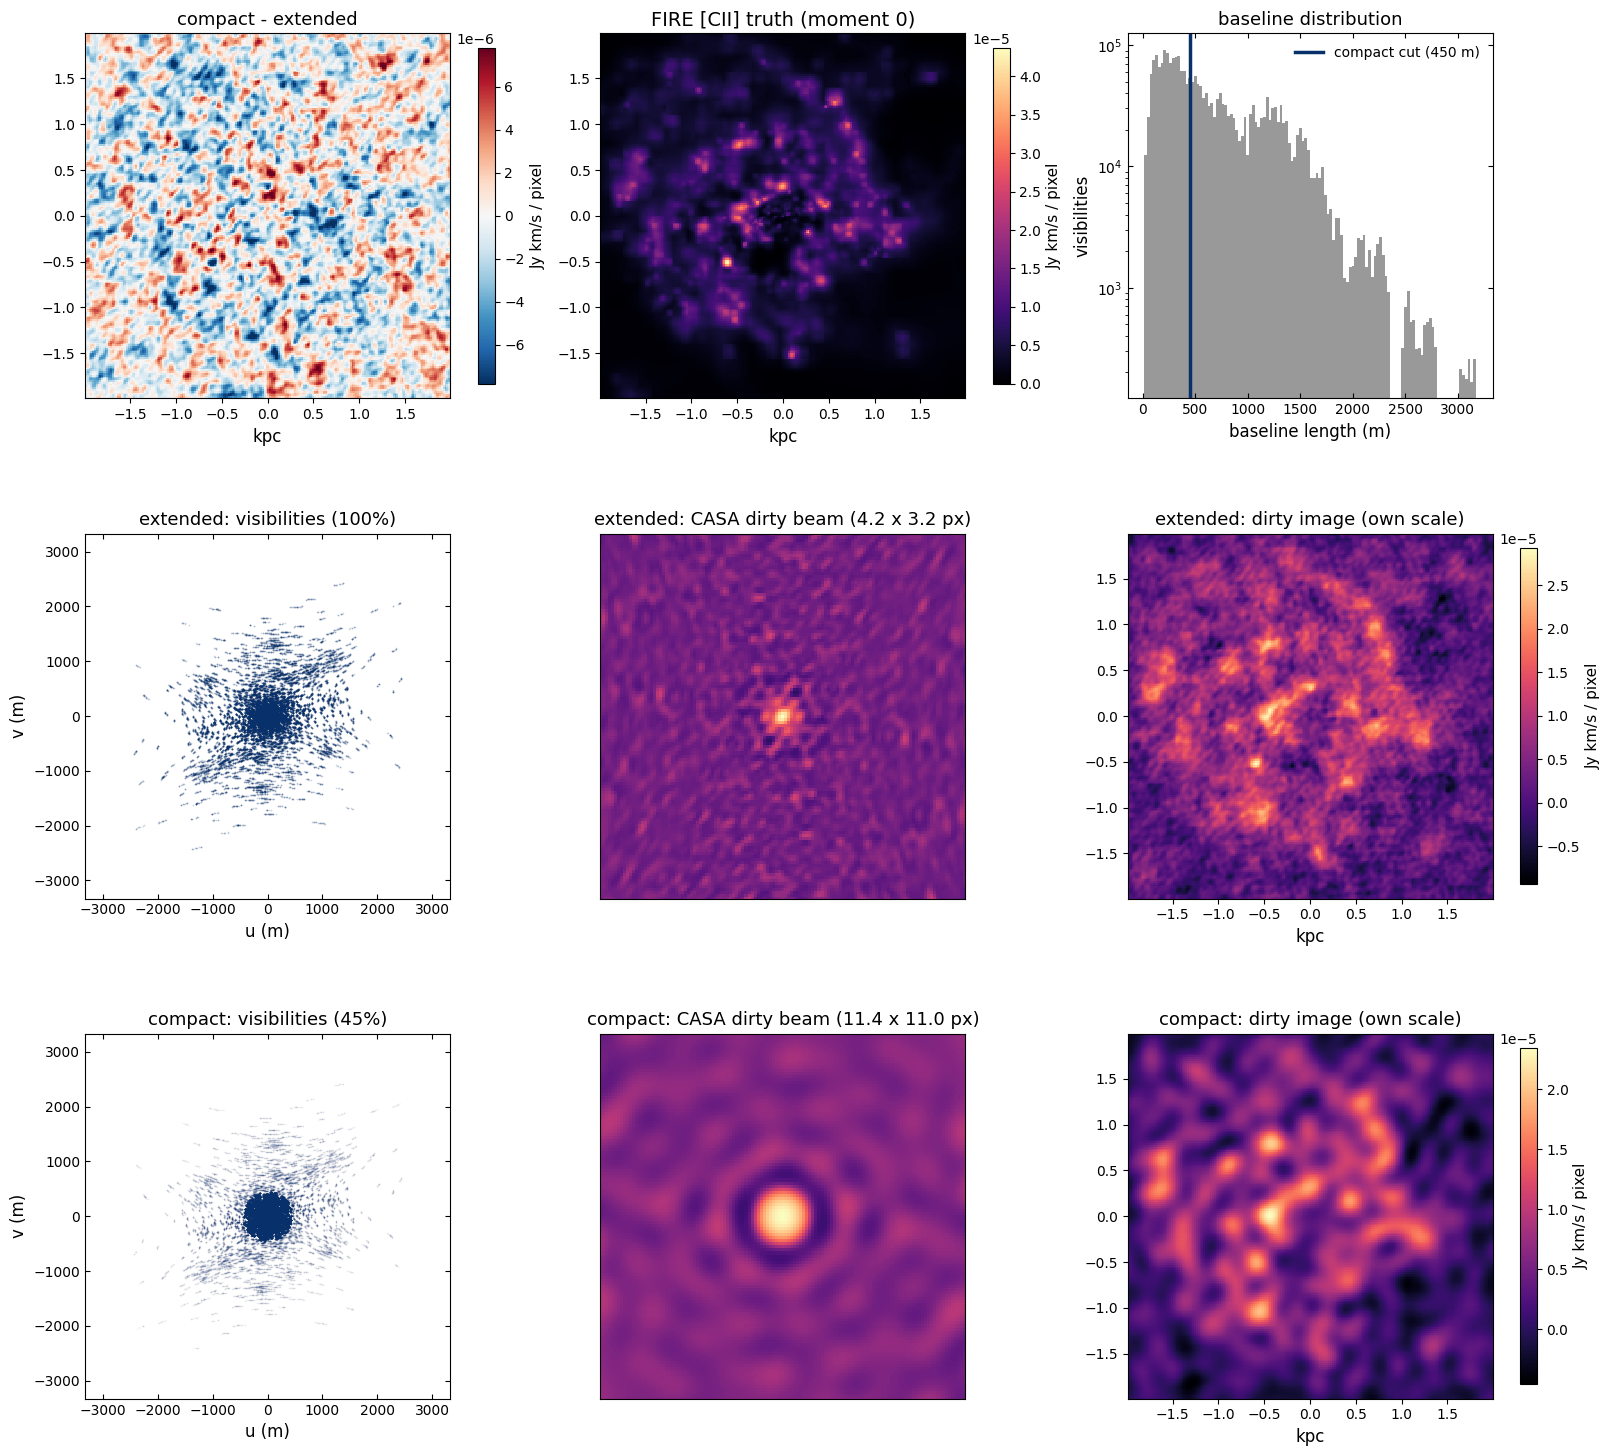

In [6]:
from matplotlib.colors import AsinhNorm

rng = np.random.default_rng(0)
VIS_COLOR = "#08306B"       # dark blue, both configs' visibility scatter
crop = slice(None)          # no embedding this time, so no cropping needed either
uv_max = uv_radius.max()

# Jy/beam -> Jy/px-equivalent by dividing out sum(PSF): the raw Jy/beam
# values aren't comparable, since the two beams collect different amounts of
# flux per beam. Beyond that, each panel gets its OWN vmin/vmax below (not a
# shared one), so the difference map is the only panel that needs a common
# frame.
dirty_common = {n: dirty_mom0[n][crop, crop] / psfs[n][n_ch // 2].sum() for n in CONFIGS}
diff_map = dirty_common["compact"] - dirty_common["extended"]

fig = plt.figure(figsize=(16, 15), constrained_layout=True)
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1])

# --- truth, spanning the top row -------------------------------------------
ax_t = fig.add_subplot(gs[0, 1])
tm = true_mom0[crop, crop]
im = ax_t.imshow(tm, origin="lower", extent=extent_kpc, cmap="magma",
                 vmin=0, vmax=tm.max(), interpolation="nearest")
ax_t.set_title("FIRE [CII] truth (moment 0)", fontsize=14)
ax_t.set_xlabel("kpc", fontsize=12)
ax_t.set_box_aspect(1)
fig.colorbar(im, ax=ax_t, fraction=0.046, pad=0.02).set_label(
    "Jy km/s / pixel", fontsize=11)

# --- baseline-length histogram, showing where the compact cut falls ---------
ax_df = fig.add_subplot(gs[0, 0])
lim = np.percentile(np.abs(diff_map), 99.5)
imd = ax_df.imshow(diff_map, origin="lower", extent=extent_kpc, cmap="RdBu_r",
                   vmin=-lim, vmax=lim, interpolation="nearest")
ax_df.set_title("compact - extended", fontsize=13)
ax_df.set_xlabel("kpc", fontsize=12)
ax_df.set_box_aspect(1)
fig.colorbar(imd, ax=ax_df, fraction=0.046, pad=0.02).set_label(
    "Jy km/s / pixel", fontsize=11)

ax_h = fig.add_subplot(gs[0, 2])
ax_h.hist(uv_radius, bins=120, color="#999999", log=True)
ax_h.axvline(COMPACT_UVDIST_M, color=VIS_COLOR, lw=2.5,
             label=f"compact cut ({COMPACT_UVDIST_M:g} m)")
ax_h.set_xlabel("baseline length (m)", fontsize=12)
ax_h.set_ylabel("visibilities", fontsize=12)
ax_h.set_title("baseline distribution", fontsize=13)
ax_h.legend(frameon=False, fontsize=10)
ax_h.tick_params(direction="in", top=True, right=True)
ax_h.set_box_aspect(1)

# --- one row per configuration ---------------------------------------------
for row, name in enumerate(CONFIGS, start=1):
    keep = CONFIGS[name]
    info = beam_info[name]

    ax_uv = fig.add_subplot(gs[row, 0])
    if name == "compact":
        # Show ALL visibilities, not just the kept subset, so the cut is
        # visible in context -- points beyond the threshold are plotted at
        # much lower opacity rather than left out entirely.
        idx_all = rng.choice(len(u_m), size=min(80000, len(u_m)), replace=False)
        kept, excluded = keep[idx_all], ~keep[idx_all]
        ax_uv.scatter(u_m[idx_all][excluded], v_m[idx_all][excluded],
                      s=1.5, alpha=0.03, color=VIS_COLOR, linewidths=0)
        ax_uv.scatter(u_m[idx_all][kept], v_m[idx_all][kept],
                      s=1.5, alpha=0.3, color=VIS_COLOR, linewidths=0)
    else:
        idx = rng.choice(np.flatnonzero(keep), size=min(40000, int(keep.sum())), replace=False)
        ax_uv.scatter(u_m[idx], v_m[idx], s=1.5, alpha=0.2, color=VIS_COLOR, linewidths=0)
    ax_uv.set_xlim(-1.05 * uv_max, 1.05 * uv_max)
    ax_uv.set_ylim(-1.05 * uv_max, 1.05 * uv_max)
    ax_uv.set_xlabel("u (m)", fontsize=12)
    ax_uv.set_ylabel("v (m)", fontsize=12)
    ax_uv.set_title(f"{name}: visibilities ({100 * info['frac']:.0f}%)", fontsize=13)
    ax_uv.set_aspect("equal", adjustable="box")
    ax_uv.tick_params(direction="in", top=True, right=True)
    ax_uv.set_box_aspect(1)

    # asinh: the main lobe (peak 1) would otherwise swamp the ~10% sidelobes
    b = psfs[name][n_ch // 2]
    scale = np.percentile(np.abs(b[b < 0.5]), 99.5)
    ax_b = fig.add_subplot(gs[row, 1])
    ax_b.imshow(b, origin="lower", cmap="magma",
                norm=AsinhNorm(linear_width=scale, vmin=-3 * scale, vmax=1.0),
                interpolation="nearest")
    ax_b.set_xlim(GRID / 2 - 60, GRID / 2 + 60)
    ax_b.set_ylim(GRID / 2 - 60, GRID / 2 + 60)
    ax_b.set_title(f"{name}: CASA dirty beam "
                   f"({info['maj']:.1f} x {info['min']:.1f} px)", fontsize=13)
    ax_b.set_xticks([])
    ax_b.set_yticks([])
    ax_b.set_box_aspect(1)

    ax_d = fig.add_subplot(gs[row, 2])
    img = dirty_common[name]
    # Genuine min/max, not clamped at 0: these carry real noise, so the
    # minimum is a real negative excursion, not just an empty-sky floor.
    im = ax_d.imshow(img, origin="lower", extent=extent_kpc, cmap="magma",
                     vmin=img.min(), vmax=img.max(), interpolation="nearest")
    ax_d.set_title(f"{name}: dirty image (own scale)", fontsize=13)
    ax_d.set_xlabel("kpc", fontsize=12)
    ax_d.set_box_aspect(1)
    fig.colorbar(im, ax=ax_d, fraction=0.046, pad=0.02).set_label(
        "Jy km/s / pixel", fontsize=11)

print(f"the two dirty maps, on a common scale: corr {np.corrcoef(*[d.ravel() for d in dirty_common.values()])[0, 1]:.4f}, "
      f"max |difference| {100 * np.abs(diff_map).max() / dirty_common['extended'].max():.1f}% of peak, "
      f"rms difference {100 * diff_map.std() / dirty_common['extended'].std():.1f}%")

plt.show()

## Extended: dirty vs. truth restored with its own clean beam

The dirty image next to the "answer key" it should be recoverable from: the
truth, smoothed to the same resolution (a Gaussian fitted to the extended
PSF's main lobe, sum-normalised so integrated flux is preserved -- the same
convention used for restoring beams elsewhere in this notebook's
deconvolution work). No noise, no sidelobes, no deconvolution -- this is
purely "what would a perfect instrument at this exact resolution see".

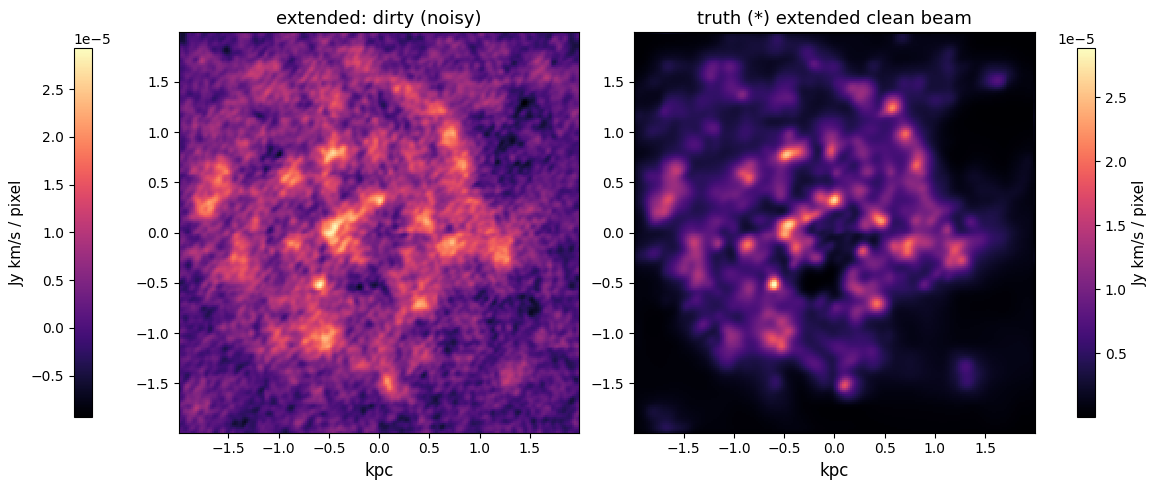

In [8]:
def clean_beam_from(b, half=25, scale=1.0):
    cy, cx = np.unravel_index(np.argmax(b), b.shape)
    sub = b[cy - half:cy + half + 1, cx - half:cx + half + 1]
    yy, xx = np.mgrid[-half:half + 1, -half:half + 1]

    def gauss2d(coords, amp, x0, y0, sx, sy, th):
        x, y = coords
        a = np.cos(th) ** 2 / (2 * sx ** 2) + np.sin(th) ** 2 / (2 * sy ** 2)
        b_ = -np.sin(2 * th) / (4 * sx ** 2) + np.sin(2 * th) / (4 * sy ** 2)
        c = np.sin(th) ** 2 / (2 * sx ** 2) + np.cos(th) ** 2 / (2 * sy ** 2)
        return amp * np.exp(-(a * (x - x0) ** 2 + 2 * b_ * (x - x0) * (y - y0)
                              + c * (y - y0) ** 2))

    lobe = sub >= 0.2
    p, _ = curve_fit(gauss2d, (xx[lobe], yy[lobe]), sub[lobe],
                     p0=[1, 0, 0, 3, 2, 0], maxfev=40000)
    n = b.shape[0]
    gy, gx = np.mgrid[:n, :n] - n // 2
    g = gauss2d((gx, gy), 1.0, 0, 0, p[3] * scale, p[4] * scale, p[5])
    return g / g.sum()


from scipy.signal import fftconvolve

clean_ext = clean_beam_from(psfs["extended"][n_ch // 2])
# mode="same" offsets by one pixel on an even grid when the kernel peaks at
# N//2; undone here, matching the convolution convention used throughout.
truth_restored = np.roll(fftconvolve(true_mom0, clean_ext, mode="same"), (-1, -1), axis=(0, 1))

dirty_ext = dirty_common["extended"]

fig, (ax_dirty, ax_truth) = plt.subplots(1, 2, figsize=(11.5, 5.4), constrained_layout=True)

im_d = ax_dirty.imshow(dirty_ext, origin="lower", extent=extent_kpc, cmap="magma",
                       vmin=dirty_ext.min(), vmax=dirty_ext.max(), interpolation="nearest")
ax_dirty.set_title("extended: dirty (noisy)", fontsize=13)
ax_dirty.set_xlabel("kpc", fontsize=12)
ax_dirty.set_box_aspect(1)
fig.colorbar(im_d, ax=ax_dirty, location="left", fraction=0.046, pad=0.06).set_label(
    "Jy km/s / pixel", fontsize=11)

im_t = ax_truth.imshow(truth_restored, origin="lower", extent=extent_kpc, cmap="magma",
                       vmin=truth_restored.min(), vmax=truth_restored.max(), interpolation="nearest")
ax_truth.set_title("truth (*) extended clean beam", fontsize=13)
ax_truth.set_xlabel("kpc", fontsize=12)
ax_truth.set_box_aspect(1)
fig.colorbar(im_t, ax=ax_truth, location="right", fraction=0.046, pad=0.06).set_label(
    "Jy km/s / pixel", fontsize=11)

plt.show()

## Can the compact array's deconvolution be trusted at the extended array's resolution?

Deconvolve the **compact** config with reweighted L1 (the same
`legacy/simple/deconvolve.py`, `REWEIGHT_MODE = "threshold"`, its tuned
default -- this is the setting that best corrects the L1 flux bias but is
also the one shown earlier to ring on sub-beam scales). Show that raw model
first, then restore it with the **extended** config's clean beam -- much
finer than the compact beam that actually constrained it -- and compare
directly against the truth restored the same way. This is the question a
real observer would actually ask: "I only have the compact array; can I
deconvolve my way to something like what the extended array would have
shown?"

In [10]:
import sys

sys.path.insert(0, "../legacy/simple")
import deconvolve as simple_deconv

DATA_DIR = "../simple_results/data"

# deconvolve.py wants (nchan, ny, nx) for both cubes; psfs[name] already is,
# dirty_cubes[name] is (ny, nx, nchan) as built above, so only it needs the
# axis move. Saved under their own filenames so this doesn't collide with
# fire_cii_config_deconvolution.ipynb's copies of the same arrays.
dirty_compact_ch = np.ascontiguousarray(np.moveaxis(dirty_cubes["compact"], 2, 0),
                                        dtype=np.float64)
psf_compact_ch = np.ascontiguousarray(psfs["compact"], dtype=np.float64)
np.save(f"{DATA_DIR}/obs_compact_psf_ch.npy", psf_compact_ch)
np.save(f"{DATA_DIR}/obs_compact_dirty_ch.npy", dirty_compact_ch)

simple_deconv.PSF_PATH = f"{DATA_DIR}/obs_compact_psf_ch.npy"
simple_deconv.DIRTY_PATH = f"{DATA_DIR}/obs_compact_dirty_ch.npy"
simple_deconv.OUT_PATH = f"{DATA_DIR}/obs_compact_model_reweighted.npy"
simple_deconv.K_SIGMA = 4.0
simple_deconv.REWEIGHT_MODE = "threshold"
simple_deconv.BURN_IN_ITERS = 20
simple_deconv.main()

model_compact = np.load(simple_deconv.OUT_PATH)             # (nchan, ny, nx), Jy/pixel
model_compact_mom0 = model_compact.sum(axis=0) * dv_rebin    # Jy km/s / pixel, RAW

[setup] zero-spacing response |sum(PSF)| = 84.93 (MEASURED -> keep coarsest band)
[setup] using the FAST operator: PSF convolution via FFT (instant, exact for a single pointing, ~0.55% rms off at this mosaic's edge)
iter   0  residual_rms=1.6691e-06  flux=    0.00 Jy  active=668239  N(model)/dirty peak=0.000
iter   5  residual_rms=1.2301e-06  flux=    0.00 Jy  active=725667  N(model)/dirty peak=0.571
iter  10  residual_rms=1.2254e-06  flux=    0.00 Jy  active=724290  N(model)/dirty peak=0.585
iter  15  residual_rms=1.2226e-06  flux=    0.00 Jy  active=724346  N(model)/dirty peak=0.593
iter  20  residual_rms=1.2219e-06  flux=    0.01 Jy  active=635240  N(model)/dirty peak=0.595
iter  25  residual_rms=1.0976e-06  flux=    0.01 Jy  active=704106  N(model)/dirty peak=0.970
iter  30  residual_rms=1.0895e-06  flux=    0.01 Jy  active=688278  N(model)/dirty peak=0.943
iter  35  residual_rms=1.0831e-06  flux=    0.01 Jy  active=674280  N(model)/dirty peak=0.950
iter  40  residual_rms=1.0802e-0

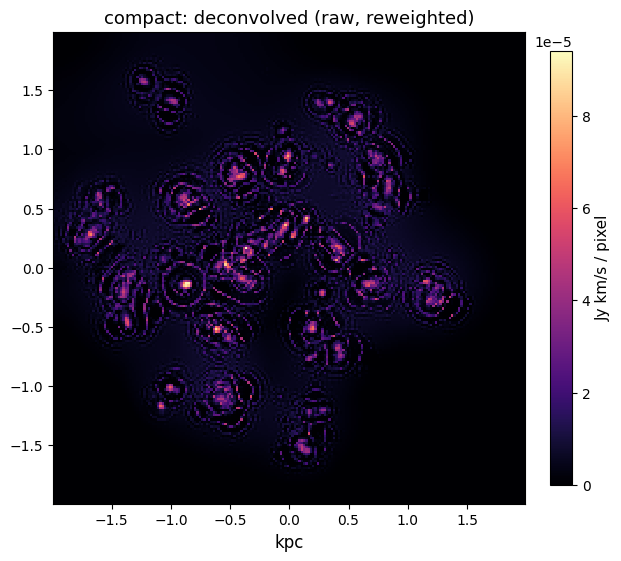

In [11]:
fig1, ax1 = plt.subplots(figsize=(6, 5.5), constrained_layout=True)
im1 = ax1.imshow(model_compact_mom0, origin="lower", extent=extent_kpc, cmap="magma",
                 vmin=model_compact_mom0.min(), vmax=model_compact_mom0.max(),
                 interpolation="nearest")
ax1.set_title("compact: deconvolved (raw, reweighted)", fontsize=13)
ax1.set_xlabel("kpc", fontsize=12)
ax1.set_box_aspect(1)
fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02).set_label(
    "Jy km/s / pixel", fontsize=11)
plt.show()

corr(compact model @ ext beam, truth @ ext beam) = 0.8927
peak: truth 2.884e-05, compact model 4.487e-05 (156%)


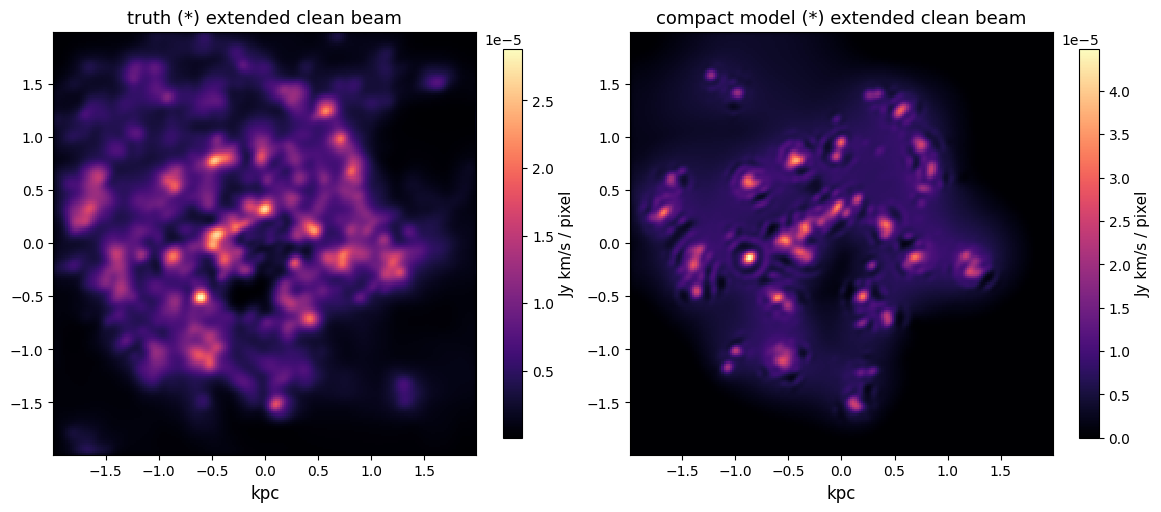

In [12]:
# Restore the compact model with the EXTENDED beam -- much finer than the
# beam that actually constrained it -- using the same sum-normalised
# (flux-conserving) kernel and even-grid shift correction as every other
# restoring step in this notebook.
model_compact_at_ext_res = np.roll(
    fftconvolve(model_compact_mom0, clean_ext, mode="same"), (-1, -1), axis=(0, 1))

fig2, (ax_truth, ax_result) = plt.subplots(1, 2, figsize=(11.5, 5.4), constrained_layout=True)

im_truth = ax_truth.imshow(truth_restored, origin="lower", extent=extent_kpc, cmap="magma",
                           vmin=truth_restored.min(), vmax=truth_restored.max(),
                           interpolation="nearest")
ax_truth.set_title("truth (*) extended clean beam", fontsize=13)
ax_truth.set_xlabel("kpc", fontsize=12)
ax_truth.set_box_aspect(1)
fig2.colorbar(im_truth, ax=ax_truth, fraction=0.046, pad=0.02).set_label(
    "Jy km/s / pixel", fontsize=11)

im_res = ax_result.imshow(model_compact_at_ext_res, origin="lower", extent=extent_kpc,
                          cmap="magma", vmin=model_compact_at_ext_res.min(),
                          vmax=model_compact_at_ext_res.max(), interpolation="nearest")
ax_result.set_title("compact model (*) extended clean beam", fontsize=13)
ax_result.set_xlabel("kpc", fontsize=12)
ax_result.set_box_aspect(1)
fig2.colorbar(im_res, ax=ax_result, fraction=0.046, pad=0.02).set_label(
    "Jy km/s / pixel", fontsize=11)

print(f"corr(compact model @ ext beam, truth @ ext beam) = "
      f"{np.corrcoef(model_compact_at_ext_res.ravel(), truth_restored.ravel())[0, 1]:.4f}")
print(f"peak: truth {truth_restored.max():.3e}, compact model {model_compact_at_ext_res.max():.3e} "
      f"({100 * model_compact_at_ext_res.max() / truth_restored.max():.0f}%)")

plt.show()

## The same thing on the real NGC 7469 data

Exactly the pattern above, but on the actual observation this whole
notebook has been testing against (`simple_results/data/psf.npy`/`dirty.npy`,
CASA-gridded from `data/ngc7469_co21.ms`, briggs robust=0.5) rather than the
simulated FIRE cube -- and reweighted deconvolution, restored at **half**
its own beam rather than a different array's beam, since there is no second
configuration here to borrow one from. There is also no ground truth for a
real observation, so the fair comparison is the dirty image itself, smoothed
to that same half-beam resolution rather than left at its native (coarser)
one -- otherwise the two panels wouldn't be showing the same resolution at
all.

In [14]:
NGC_DV_KMS = 5.0   # legacy/simple/grid_with_casa.py's WIDTH_KMS
NGC_CELL_ARCSEC = 0.04

ngc_psf = np.load(f"{DATA_DIR}/psf.npy")      # (nchan, ny, nx), already the
ngc_dirty = np.load(f"{DATA_DIR}/dirty.npy")  # shape deconvolve.py wants -- no
                                              # axis juggling needed, unlike FIRE
ngc_nchan = ngc_psf.shape[0]
ngc_extent = np.array([-1, 1, -1, 1]) * ngc_psf.shape[1] / 2 * NGC_CELL_ARCSEC

simple_deconv.PSF_PATH = f"{DATA_DIR}/psf.npy"
simple_deconv.DIRTY_PATH = f"{DATA_DIR}/dirty.npy"
simple_deconv.OUT_PATH = f"{DATA_DIR}/obs_ngc_model_reweighted.npy"
simple_deconv.K_SIGMA = 4.0
simple_deconv.REWEIGHT_MODE = "threshold"
simple_deconv.BURN_IN_ITERS = 20
simple_deconv.main()

model_ngc = np.load(simple_deconv.OUT_PATH)
model_ngc_mom0 = model_ngc.sum(axis=0) * NGC_DV_KMS   # Jy km/s / pixel, RAW

[setup] zero-spacing response |sum(PSF)| = 52.20 (MEASURED -> keep coarsest band)
[setup] using the FAST operator: PSF convolution via FFT (instant, exact for a single pointing, ~0.55% rms off at this mosaic's edge)
iter   0  residual_rms=1.5917e-03  flux=   17.68 Jy  active=1898128  N(model)/dirty peak=0.000
iter   5  residual_rms=8.9041e-04  flux=   60.79 Jy  active=1638774  N(model)/dirty peak=0.788
iter  10  residual_rms=8.6817e-04  flux=   61.79 Jy  active=1623545  N(model)/dirty peak=0.850
iter  15  residual_rms=8.7110e-04  flux=   61.41 Jy  active=1623501  N(model)/dirty peak=0.846
iter  20  residual_rms=8.7037e-04  flux=   68.43 Jy  active=1123549  N(model)/dirty peak=0.844
iter  25  residual_rms=7.5703e-04  flux=  100.77 Jy  active=1289262  N(model)/dirty peak=1.037
iter  30  residual_rms=7.3739e-04  flux=   94.86 Jy  active=1314784  N(model)/dirty peak=0.994
iter  35  residual_rms=7.3497e-04  flux=   96.67 Jy  active=1322539  N(model)/dirty peak=0.980
iter  40  residual_rms=7

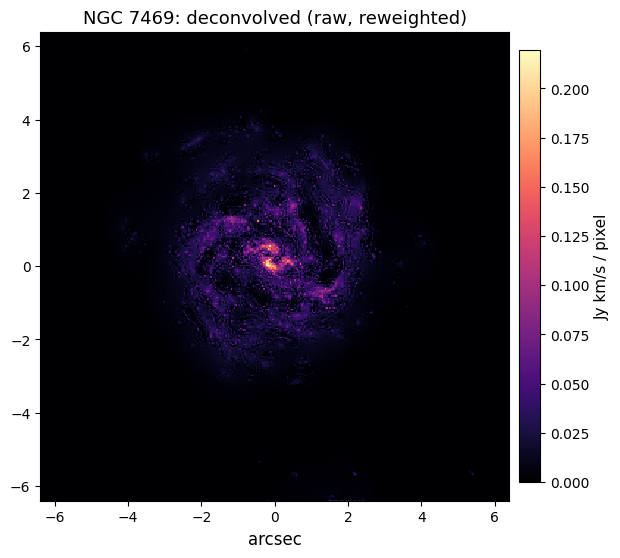

In [15]:
fig3, ax3 = plt.subplots(figsize=(6, 5.5), constrained_layout=True)
im3 = ax3.imshow(model_ngc_mom0, origin="lower", extent=ngc_extent, cmap="magma",
                 vmin=model_ngc_mom0.min(), vmax=model_ngc_mom0.max(),
                 interpolation="nearest")
ax3.set_title("NGC 7469: deconvolved (raw, reweighted)", fontsize=13)
ax3.set_xlabel("arcsec", fontsize=12)
ax3.set_box_aspect(1)
fig3.colorbar(im3, ax=ax3, fraction=0.046, pad=0.02).set_label(
    "Jy km/s / pixel", fontsize=11)
plt.show()

corr(model @ half beam, dirty @ half beam) = 0.8162


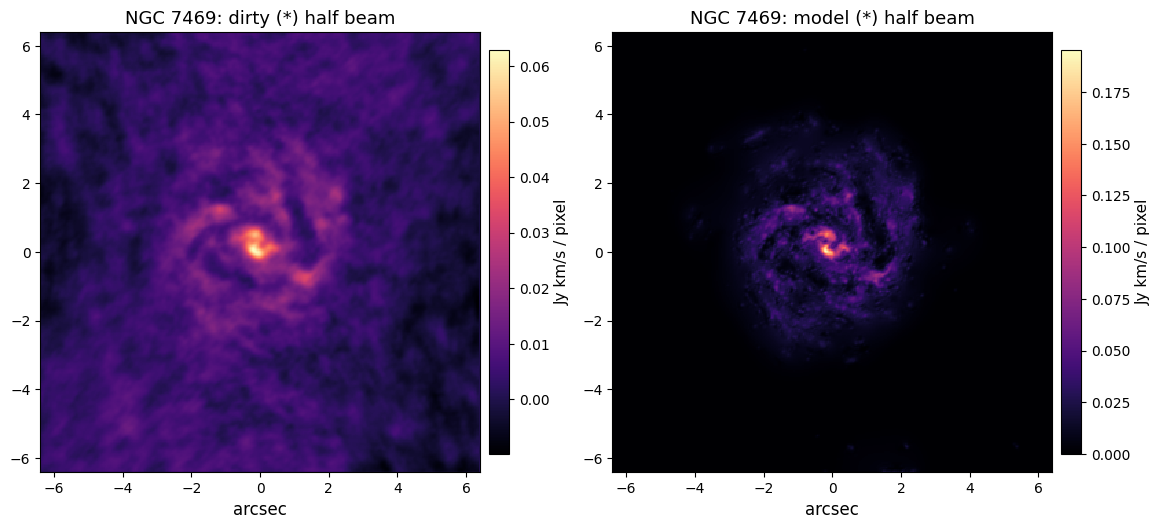

In [16]:
clean_ngc_half = clean_beam_from(ngc_psf[ngc_nchan // 2], scale=0.5)


def smooth_ngc(img):
    return np.roll(fftconvolve(img, clean_ngc_half, mode="same"), (-1, -1), axis=(0, 1))


ngc_dirty_mom0 = ngc_dirty.sum(axis=0) * NGC_DV_KMS / ngc_psf[ngc_nchan // 2].sum()
ngc_dirty_at_half = smooth_ngc(ngc_dirty_mom0)          # same resolution as the model below
model_ngc_at_half = smooth_ngc(model_ngc_mom0)

fig4, (ax_d, ax_m) = plt.subplots(1, 2, figsize=(11.5, 5.4), constrained_layout=True)

im_d = ax_d.imshow(ngc_dirty_at_half, origin="lower", extent=ngc_extent, cmap="magma",
                   vmin=ngc_dirty_at_half.min(), vmax=ngc_dirty_at_half.max(),
                   interpolation="nearest")
ax_d.set_title("NGC 7469: dirty (*) half beam", fontsize=13)
ax_d.set_xlabel("arcsec", fontsize=12)
ax_d.set_box_aspect(1)
fig4.colorbar(im_d, ax=ax_d, fraction=0.046, pad=0.02).set_label(
    "Jy km/s / pixel", fontsize=11)

im_m = ax_m.imshow(model_ngc_at_half, origin="lower", extent=ngc_extent, cmap="magma",
                   vmin=model_ngc_at_half.min(), vmax=model_ngc_at_half.max(),
                   interpolation="nearest")
ax_m.set_title("NGC 7469: model (*) half beam", fontsize=13)
ax_m.set_xlabel("arcsec", fontsize=12)
ax_m.set_box_aspect(1)
fig4.colorbar(im_m, ax=ax_m, fraction=0.046, pad=0.02).set_label(
    "Jy km/s / pixel", fontsize=11)

print(f"corr(model @ half beam, dirty @ half beam) = "
      f"{np.corrcoef(model_ngc_at_half.ravel(), ngc_dirty_at_half.ravel())[0, 1]:.4f}")

plt.show()